<a href="https://colab.research.google.com/github/vhugo23/AI-ML-Research-Summer-2025/blob/trying-stuff/LSTM2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving water_consumption_sub.csv to water_consumption_sub.csv


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
445/445 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.0561 - val_loss: 4.3796e-04
Epoch 2/50
445/445 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 8.3376e-04 - val_loss: 3.9771e-04
Epoch 3/50
445/445 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 6.0570e-04 - val_loss: 2.2855e-04
Epoch 4/50
445/445 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 4.6363e-04 - val_loss: 2.8889e-04
Epoch 5/50
445/445 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 4.3637e-04 - val_loss: 2.7858e-04
Epoch 6/50
445/445 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 4.6607e-04 - val_loss: 2.8324e-04
Epoch 7/50
445/445 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 4.6221e-04 - val_loss: 1.8045e-04
Epoch 8/50
445/445 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 3.9409e-04 - val_loss: 1.5714e-04
Epoch 9/50
445/445 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 3.4734e-04 - val_loss: 1.5235e-04
Epoch 10/50
445/445 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 3.7221e-04 - val_loss: 1.8001e-04
Epoch 11/50
445/445 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 

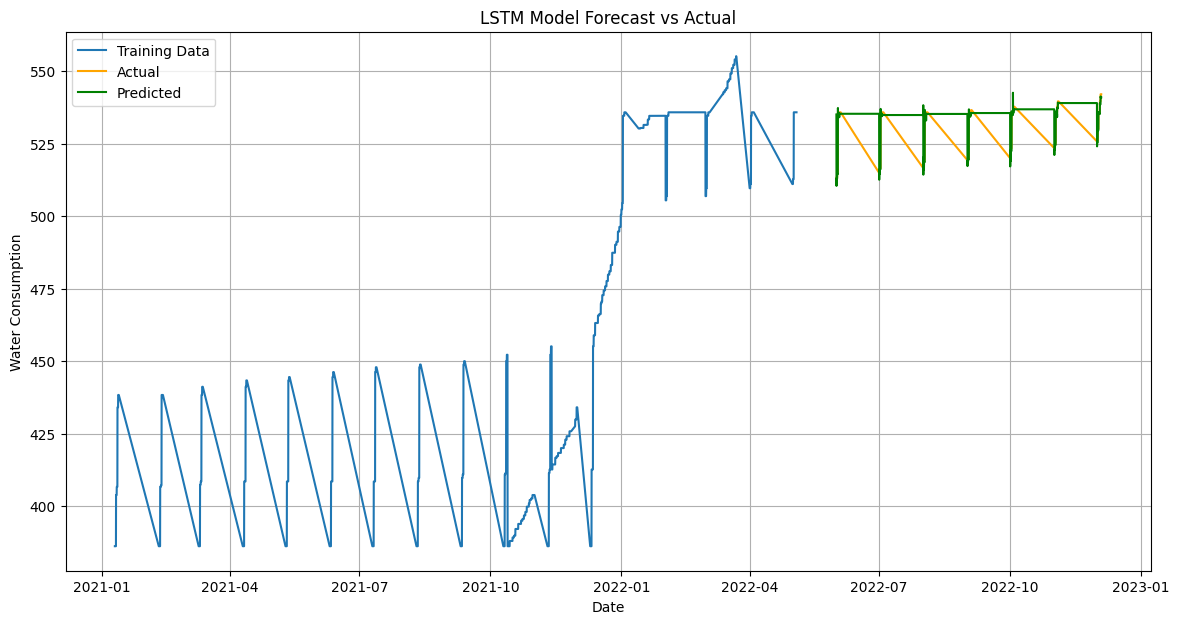

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Load and clean data
df = pd.read_csv('water_consumption_sub.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.rename(columns={'timestamp': 'ds', 'consumption': 'y'}, inplace=True)
df = df.dropna(subset=['y'])
df = df[df['y'] > 0]

# Create lag and rolling window features
df['y_lag1'] = df['y'].shift(1)
df['y_lag7'] = df['y'].shift(7)
df['y_roll_mean_7'] = df['y'].rolling(window=7).mean()

# Add time-based features
df['day_of_week'] = df['ds'].dt.dayofweek
df['is_weekend'] = (df['ds'].dt.weekday >= 5).astype(int)
df.dropna(inplace=True)

# Define features
features = ['y_lag1', 'y_lag7', 'y_roll_mean_7', 'day_of_week', 'is_weekend']

# Scale data
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()
scaled_features = feature_scaler.fit_transform(df[features])
scaled_target = target_scaler.fit_transform(df[['y']])
scaled_data = np.hstack((scaled_features, scaled_target))

# Sequence creator
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i - seq_length:i, :-1])
        y.append(data[i, -1])
    return np.array(X), np.array(y)

# Create sequences
seq_length = 14
X, y = create_sequences(scaled_data, seq_length)
dates = df['ds'].iloc[seq_length:].reset_index(drop=True)

# Split train/test by date
split_date = pd.to_datetime('2022-06-01')
train_idx = dates < split_date
test_idx = dates >= split_date
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
dates_train, dates_test = dates[train_idx], dates[test_idx]

# Build LSTM
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    tf.keras.layers.Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# Predictions
y_pred = model.predict(X_test)
y_test_inv = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_inv = target_scaler.inverse_transform(y_pred).flatten()

# Evaluation
mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mape = np.mean(np.abs((y_test_inv - y_pred_inv) / np.maximum(y_test_inv, 1e-8))) * 100

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

# Plotting
plt.figure(figsize=(14, 7))
plt.plot(dates_train, target_scaler.inverse_transform(y_train.reshape(-1, 1)).flatten(), label='Training Data')
plt.plot(dates_test, y_test_inv, label='Actual', color='orange')
plt.plot(dates_test, y_pred_inv, label='Predicted', color='green')
plt.xlabel('Date')
plt.ylabel('Water Consumption')
plt.title('LSTM Model Forecast vs Actual')
plt.legend()
plt.grid(True)
plt.show()


In [3]:
1# Double-check the date range of your dataset
print(df['ds'].min(), df['ds'].max())

2021-01-10 01:45:00 2022-12-03 23:45:00


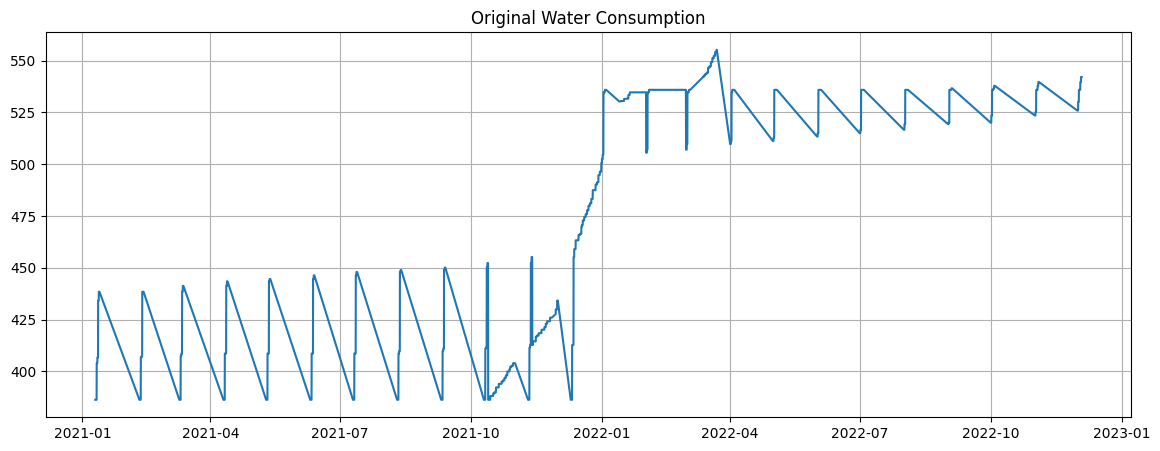

In [4]:
2# Visualize the raw water consumption before moedeling
plt.figure(figsize=(14, 5))
plt.plot(df['ds'], df['y'])
plt.title('Original Water Consumption')
plt.grid(True)
plt.show()


In [5]:
3# Try a more recent split_date(like '2022-04-01') to ensure enough high-quality training data exists
split_date = pd.to_datetime('2022-04-01')


In [9]:
4# Check for missing or repated timestamps
print(df['ds'].duplicated().sum())
print(df['ds'].isna().sum())


0
0


In [10]:
5# Review our current df.head() and df.tail()
print(df.head(10))
print(df.tail(10))


          ds  campus_id  meter_id          y     y_lag1     y_lag7  \
0 2021-01-10         89       445  34377.496  34377.496  34377.496   
1 2021-01-11         96       480  38914.020  38893.549  38770.723   
2 2021-01-12         95       475  41453.940  41422.255  41232.145   
3 2021-01-13          0         0      0.000      0.000      0.000   
4 2021-01-14          0         0      0.000      0.000      0.000   
5 2021-01-15          0         0      0.000      0.000      0.000   
6 2021-01-16          0         0      0.000      0.000      0.000   
7 2021-01-17          0         0      0.000      0.000      0.000   
8 2021-01-18          0         0      0.000      0.000      0.000   
9 2021-01-19          0         0      0.000      0.000      0.000   

   y_roll_mean_7  day_of_week  is_weekend  
0      34377.496          534          89  
1      38852.607            0           0  
2      41358.885           95           0  
3          0.000            0           0  
4        

**Possible fixes I need to make**

1. Clean the Data:
Remove all rows where y = 0 or campus_id = 0
(df = df[(df['y'] > 0) & (df['campus_id'] > 0)]
)
2. Fix Day-of-Week Columns: Make sure they're derived from ds, not the index or wrong column.
(df['day_of_week'] = df['ds'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int))

3. Check Again: Pint the head and tail to ensure the columns make sense.
(print(df[['ds', 'y', 'day_of_week', 'is_weekend']].head(10))
print(df[['ds', 'y', 'day_of_week', 'is_weekend']].tail(10)))

4. Rebuild everything:Recalculate lag features, re-scale data, re-split train/test, re-train my LSTM model

The initial LSTM graph showed poor behavior due to corrupted rows in the dataset containg many zeros and improperly computed features (e.g, day of week). After filtering out invalid entries and fixing the time-based features, the model can better learn from consistent, real consumption data and genralize to future predictions